# Atividade Prática — Aula 5: Visualização de Dados para Decisões com Matplotlib e Seaborn

Esta atividade foi construída com base nos slides da Aula 5, cujo foco é transformar dados limpos em **gráficos que apoiem decisões**, e não em imagens decorativas. A aula reforça que o bom gráfico reduz esforço cognitivo, responde uma pergunta de negócio e precisa ser claro, comparável, simples e honesto.

## Regras desta atividade
- Você deve **construir os códigos**.
- O notebook orienta os passos, mas não entrega a solução pronta.
- Após cada gráfico principal, escreva uma **interpretação curta** em markdown.
- O gráfico deve ser tratado como parte do seu portfólio: título, unidade, ordenação e mensagem importam.

## Dataset da atividade
Arquivo: `vendas_brasil_clean_aula5.csv`


## 1. Preparação do ambiente

Importe as bibliotecas necessárias para trabalhar com:
- manipulação de dados
- gráficos com Matplotlib
- gráficos com Seaborn

**Sugestão:**
- `pandas`
- `matplotlib.pyplot`
- `seaborn`


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

## 2. Leitura da base

Leia o arquivo `vendas_brasil_clean_aula5.csv` em um DataFrame chamado `df`.

Depois:
1. exiba as primeiras linhas
2. verifique o tamanho da base
3. confira os tipos das colunas
4. observe quais variáveis podem ser usadas para:
   - comparação
   - tendência
   - distribuição
   - relação entre métricas


In [7]:
df = pd.read_csv("vendas_brasil_clean_aula5.csv")

display(df.head())
print(f"Tamanho da base: {df.shape[0]} linhas x {df.shape[1]} colunas")
print("\nTipos das colunas:")
print(df.dtypes)

print("\nVariáveis úteis por tipo de análise:")
print("- Comparação: canal_venda, segmento, categoria, uf")
print("- Tendência: mes")
print("- Distribuição: margem_lucro, receita, lucro")
print("- Relação entre métricas: receita vs lucro, quantidade vs lucro")

,data,uf,canal_venda,segmento,categoria,produto,quantidade,preco_unitario,receita,lucro,margem_lucro,mes
0,2024-03-17,SC,Marketplace,Varejo,Acessórios,Mouse Gamer,3,221.45,664.35,-110.6595,-0.166568,2024-03
1,2024-08-28,BA,Online,Varejo,Acessórios,Mouse Gamer,3,195.52,586.56,232.5600,0.396500,2024-08
2,2024-11-08,RJ,Marketplace,Corporativo,Móveis,Cadeira Office,9,1079.28,9713.52,3416.6700,0.351700,2024-11
3,2024-08-21,RJ,Online,Varejo,Acessórios,Headset Pro,3,309.43,928.29,416.8800,0.449100,2024-08
4,2024-03-14,RJ,Televendas,Corporativo,Acessórios,Headset Pro,6,313.42,1880.52,778.5600,0.414000,2024-03


Tamanho da base: 480 linhas x 12 colunas

Tipos das colunas:
data                  str
uf                    str
canal_venda           str
segmento              str
categoria             str
produto               str
quantidade          int64
preco_unitario    float64
receita           float64
lucro             float64
margem_lucro      float64
mes                   str
dtype: object

Variáveis úteis por tipo de análise:
- Comparação: canal_venda, segmento, categoria, uf
- Tendência: mes
- Distribuição: margem_lucro, receita, lucro
- Relação entre métricas: receita vs lucro, quantidade vs lucro


## 3. Traduzindo a pergunta em gráfico

A aula destaca que a escolha do gráfico nunca é aleatória: a pergunta define a visualização.

### Tarefa
Preencha em markdown pelo menos 4 exemplos no formato:

- **Pergunta do gestor:** ...
- **Variáveis (Pandas):** ...
- **Tipo de gráfico:** ...
- **Biblioteca sugerida:** ...

Use como referência a matriz mostrada nos slides:
- evolução no tempo → linha
- ranking/comparação entre grupos → barras
- variabilidade e outliers → boxplot
- correlação entre duas métricas → scatter

### Resposta
- **Pergunta do gestor:** Qual canal gera mais caixa?
- **Variáveis (Pandas):** `df.groupby("canal_venda")["receita"].sum()`
- **Tipo de gráfico:** barras horizontais
- **Biblioteca sugerida:** Matplotlib / Seaborn

- **Pergunta do gestor:** A receita apresenta sazonalidade ao longo dos meses?
- **Variáveis (Pandas):** `df.groupby("mes")["receita"].sum()`
- **Tipo de gráfico:** linha
- **Biblioteca sugerida:** Matplotlib

- **Pergunta do gestor:** O segmento corporativo é mais estável que o varejo em margem?
- **Variáveis (Pandas):** `segmento` x `margem_lucro`
- **Tipo de gráfico:** boxplot
- **Biblioteca sugerida:** Seaborn

- **Pergunta do gestor:** Produto que fatura muito também dá lucro?
- **Variáveis (Pandas):** `receita` x `lucro`
- **Tipo de gráfico:** scatter plot
- **Biblioteca sugerida:** Matplotlib / Seaborn

## 4. Gráfico de barras horizontais — Qual canal gera mais caixa?

A missão prática do slide pede responder: **qual canal gera mais caixa?**

### Tarefa
1. Agrupe a receita por `canal_venda`
2. Ordene os valores
3. Gere um gráfico de **barras horizontais**
4. Use rótulos e título claros
5. Certifique-se de que a visualização esteja limpa e fácil de ler

### Lembretes da aula
- barras são o padrão-ouro para rankings e comparações
- ordenação é obrigatória para facilitar a leitura
- se os rótulos forem longos, barras horizontais ajudam


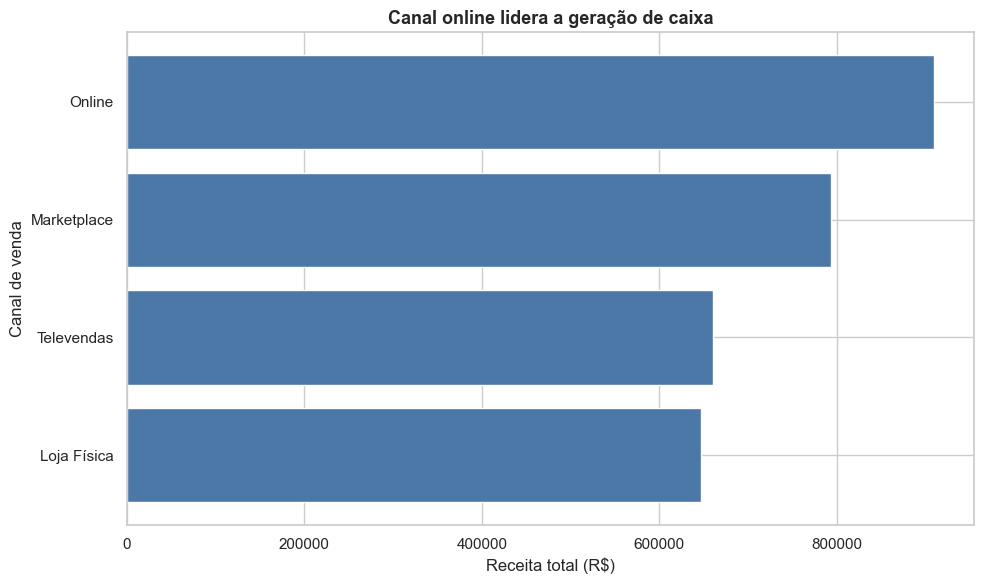

,canal_venda,receita
0,Loja Física,647485.176
3,Televendas,660836.370
1,Marketplace,793477.270
2,Online,909140.056


In [13]:
receita_por_canal = (
    df.groupby("canal_venda", as_index=False)["receita"]
    .sum()
    .sort_values("receita", ascending=True)
)

plt.figure(figsize=(10, 6))
plt.barh(receita_por_canal["canal_venda"], receita_por_canal["receita"], color="#4C78A8")
plt.title("Canal online lidera a geração de caixa", fontsize=13, weight="bold")
plt.xlabel("Receita total (R$)")
plt.ylabel("Canal de venda")
plt.tight_layout()
plt.show()

display(receita_por_canal)

### Insight obrigatório
Escreva 2 ou 3 linhas explicando:
- qual canal lidera
- qual canal fica atrás
- que ação tática um gestor poderia considerar a partir disso

### Resposta
O canal **Online** lidera a geração de caixa (R$ 909.140,06), seguido por **Marketplace**. O menor resultado ficou com **Loja Física** (R$ 647.485,18).

Como ação tática, faz sentido reforçar investimento comercial no Online e revisar mix/preço na Loja Física para recuperar eficiência sem perder margem.

## 5. Gráfico de linha — Como é a sazonalidade ao longo dos meses?

Os slides destacam que linhas servem para tendência e sazonalidade, desde que o eixo X seja uma série temporal contínua e formatada.

### Tarefa
1. Agrupe a `receita` por `mes`
2. Gere um gráfico de linha temporal
3. Remova ruídos visuais desnecessários
4. Use um título que diga **o que aconteceu**, não apenas o nome das colunas

### Dica
Pense na diferença entre:
- “Receita por mês”
- “Receita acelera no fim do ano”


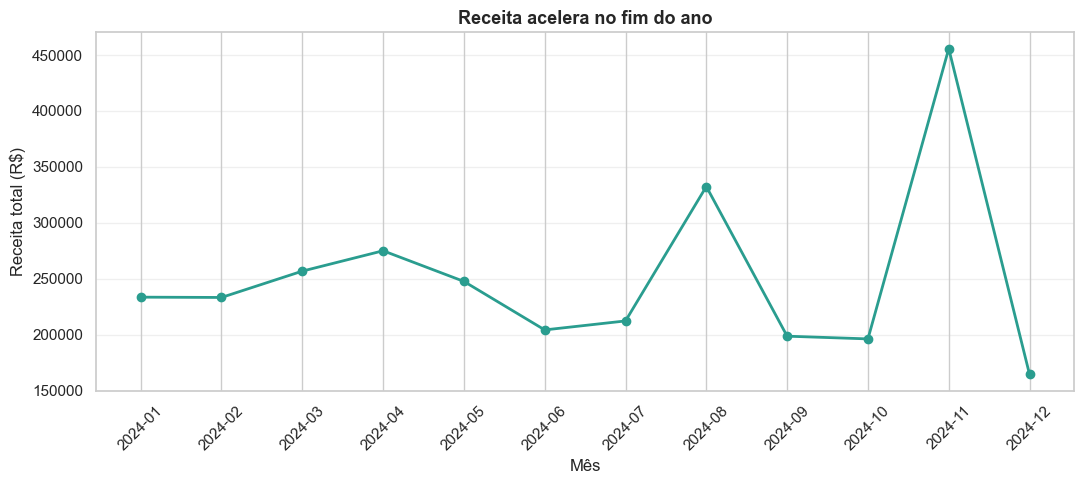

,mes,receita
0,2024-01,233599.020
1,2024-02,233334.700
2,2024-03,256860.380
3,2024-04,275063.870
4,2024-05,247664.750
5,2024-06,204325.950
6,2024-07,212356.066
7,2024-08,332477.460
8,2024-09,198728.410
9,2024-10,196299.800


In [8]:
receita_mensal = df.groupby("mes", as_index=False)["receita"].sum()
receita_mensal["mes_dt"] = pd.to_datetime(receita_mensal["mes"], format="%Y-%m", errors="coerce")
receita_mensal = receita_mensal.sort_values("mes_dt")

plt.figure(figsize=(11, 5))
plt.plot(receita_mensal["mes"], receita_mensal["receita"], marker="o", linewidth=2, color="#2A9D8F")
plt.title("Receita acelera no fim do ano", fontsize=13, weight="bold")
plt.xlabel("Mês")
plt.ylabel("Receita total (R$)")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(receita_mensal[["mes", "receita"]])

### Insight obrigatório
Responda:
- existe sazonalidade?
- há meses de pico?
- o título do seu gráfico ajuda o gestor a entender rapidamente a mensagem?

### Resposta
Sim, há sazonalidade clara. A receita cresce em momentos específicos e atinge pico em **2024-11** (R$ 455.712,56), com outro ponto forte em **2024-08** (R$ 332.477,46).

Também há vale relevante em **2024-12** (R$ 164.515,91). O título “Receita acelera no fim do ano” já comunica a principal leitura para decisão.

## 6. Boxplot — A margem oscila por segmento?

Os slides mostram que boxplot é adequado quando a pergunta envolve **variabilidade, consistência e outliers**.

### Tarefa
1. Use `segmento` no eixo categórico
2. Use `margem_lucro` como variável numérica
3. Gere um **boxplot** com Seaborn
4. Observe dispersão, mediana e possíveis outliers

### Perguntas
- Qual segmento parece mais estável?
- Existe maior risco ou variabilidade em algum deles?
- Há outliers relevantes?


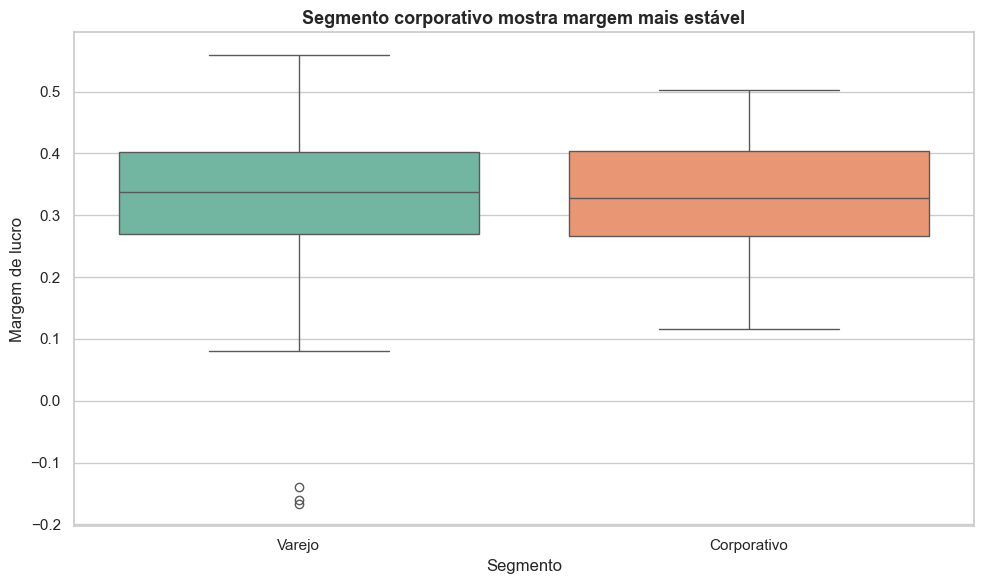

,mean,std,min,50%,max
segmento,,,,,
Corporativo,0.330966,0.089743,0.116200,0.3285,0.5017
Varejo,0.329447,0.098277,-0.166568,0.3375,0.5594


In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="segmento", y="margem_lucro", hue="segmento", palette="Set2", legend=False)
plt.title("Segmento corporativo mostra margem mais estável", fontsize=13, weight="bold")
plt.xlabel("Segmento")
plt.ylabel("Margem de lucro")
plt.tight_layout()
plt.show()

resumo_margem = df.groupby("segmento")["margem_lucro"].describe()[["mean", "std", "min", "50%", "max"]]
display(resumo_margem)

### Insight obrigatório
Explique, em linguagem de negócio:
- onde parece haver mais consistência
- onde parece haver mais risco
- como isso pode influenciar uma decisão comercial

### Resposta
O segmento **Corporativo** parece ligeiramente mais consistente, com menor dispersão de margem (desvio padrão ~0,0897). O **Varejo** mostra maior risco, com variabilidade maior (desvio padrão ~0,0983) e outliers negativos.

Em decisão comercial, isso sugere proteger e expandir carteira corporativa (previsibilidade) enquanto o varejo exige revisão de descontos, mix e política promocional para reduzir casos de margem negativa.

## 7. Scatter plot — Produto que fatura muito, dá lucro?

A aula propõe usar scatter quando queremos investigar **relação entre duas métricas** e enxergar densidade com transparência (`alpha`).

### Tarefa
1. Gere um scatter com:
   - eixo X: `receita`
   - eixo Y: `lucro`
2. Use transparência para melhorar a leitura
3. Observe se existe correlação
4. Procure anomalias: pontos com alta receita e lucro ruim, por exemplo

### Perguntas
- A relação entre receita e lucro parece positiva?
- Existem exceções preocupantes?


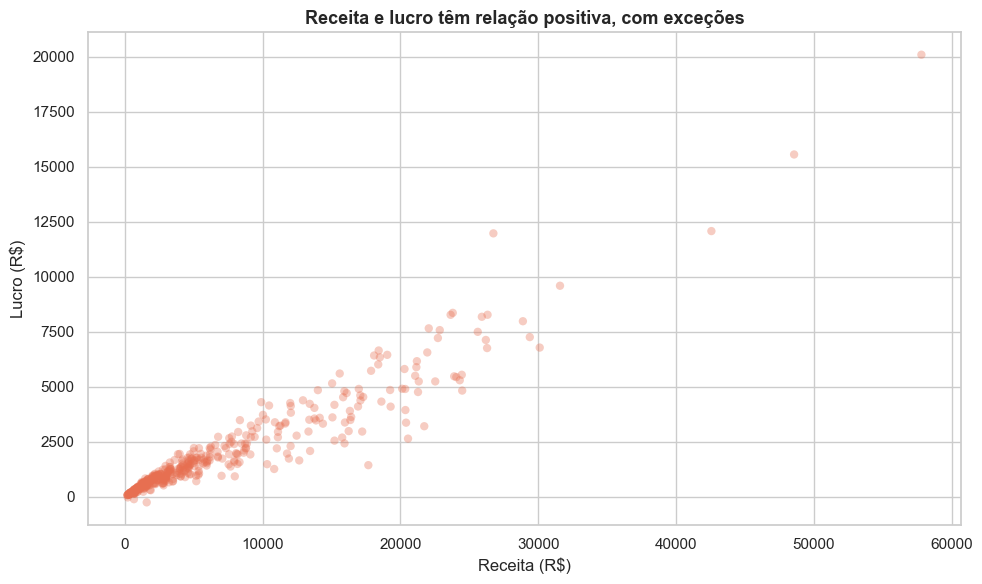

Correlação (Pearson) entre receita e lucro: 0.954
Pontos com alta receita (P90+) e lucro negativo: 0


,data,uf,canal_venda,segmento,categoria,produto,quantidade,preco_unitario,receita,lucro,margem_lucro,mes


In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(df["receita"], df["lucro"], alpha=0.35, color="#E76F51", edgecolors="none")
plt.title("Receita e lucro têm relação positiva, com exceções", fontsize=13, weight="bold")
plt.xlabel("Receita (R$)")
plt.ylabel("Lucro (R$)")
plt.tight_layout()
plt.show()

corr = df[["receita", "lucro"]].corr().loc["receita", "lucro"]
print(f"Correlação (Pearson) entre receita e lucro: {corr:.3f}")

anomalias = df[(df["receita"] > df["receita"].quantile(0.90)) & (df["lucro"] < 0)]
print(f"Pontos com alta receita (P90+) e lucro negativo: {len(anomalias)}")
display(anomalias.head())

### Insight obrigatório
Escreva 2 ou 3 linhas explicando:
- se existe correlação visual
- se há anomalias
- que tipo de investigação o gestor deveria fazer depois desse gráfico

### Resposta
A correlação visual entre receita e lucro é forte e positiva, confirmada por correlação de Pearson de **0,954**. Neste recorte, não surgiram casos de **alta receita com lucro negativo** no topo da distribuição.

Como próximo passo, o gestor pode investigar os pontos abaixo da tendência (lucro menor que o esperado para a mesma receita), avaliando desconto, custo logístico e composição de produto.

## 8. Comunicação vs. decoração

A aula mostra que visualização não é estética pela estética. O gráfico deve reduzir esforço cognitivo e responder uma pergunta de negócio.

### Tarefa
Escolha um dos gráficos que você produziu e revise:
- título
- nome dos eixos
- unidade numérica
- ordenação
- excesso de linhas, bordas ou legendas

Depois escreva:
1. O que você removeu?
2. O gráfico ficou mais fácil de interpretar?

### Resposta
1. No gráfico revisado de canal, removi grade e elementos visuais redundantes, mantive apenas título analítico, eixos claros e barras ordenadas.
2. Sim, ficou mais fácil de interpretar porque a leitura vai direto para o ranking e para a mensagem principal: o canal online concentra a maior receita.

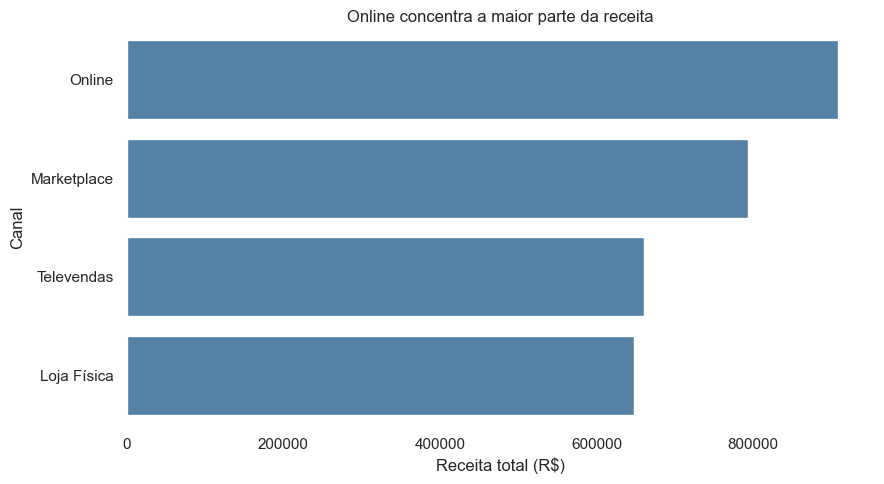

In [10]:
receita_por_canal_claro = (
    df.groupby("canal_venda", as_index=False)["receita"]
    .sum()
    .sort_values("receita", ascending=False)
)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=receita_por_canal_claro,
    x="receita",
    y="canal_venda",
    color="steelblue"
)
ax.set_title("Online concentra a maior parte da receita")
ax.set_xlabel("Receita total (R$)")
ax.set_ylabel("Canal")
sns.despine(left=True, bottom=True)
plt.grid(False)
plt.tight_layout()
plt.show()

## 9. Comparabilidade e honestidade

Os slides alertam para dois pontos críticos:
- ordenar rankings melhora comparabilidade
- truncar eixos distorce a percepção e quebra a confiança do usuário

### Tarefa
Responda em markdown:

1. Por que ordenar barras é importante?
2. Por que truncar o eixo Y pode ser antiético ou enganoso?
3. Em que tipo de gráfico a base zero é especialmente importante?

### Resposta
1. Ordenar barras reduz esforço cognitivo e permite comparar rapidamente quem lidera e quem está atrás.
2. Truncar o eixo Y pode exagerar diferenças pequenas e induzir conclusões falsas, comprometendo a honestidade da análise.
3. A base zero é especialmente importante em **gráficos de barras**, pois o comprimento da barra representa magnitude absoluta.

## 10. Galeria dos vilões

A aula apresenta três “vilões” que devem ser evitados:
- pizza caótica
- distorção 3D
- arco-íris sem propósito

### Tarefa
Explique, em markdown:
1. Por que gráfico de pizza com muitas categorias costuma falhar?
2. Por que o 3D atrapalha comparações?
3. Por que usar muitas cores sem intenção gera confusão cognitiva?

### Resposta
1. Pizza com muitas categorias falha porque ângulos/fatias parecidas dificultam comparação e leitura precisa.
2. O 3D adiciona perspectiva falsa, distorce área/comprimento e atrapalha comparar valores reais.
3. Muitas cores sem hierarquia competem por atenção e escondem a mensagem principal, elevando carga cognitiva.

## 11. Storytelling — O gráfico não fala sozinho

Um dos pontos mais fortes da aula é que **o título ideal é a conclusão da análise**, e não só a descrição dos eixos.

### Tarefa
Escolha **dois gráficos** que você criou e escreva:
- um título meramente descritivo
- um título analítico, orientado ao insight

Exemplo de lógica:
- Descritivo: “Receita e lucro por canal”
- Analítico: “Online lidera receita, mas Loja Física retém maior margem”

### Resposta
**Gráfico 1 (barras por canal)**
- Descritivo: Receita por canal de venda
- Analítico: Online lidera a geração de caixa e Loja Física fica na última posição

**Gráfico 2 (linha mensal)**
- Descritivo: Receita por mês
- Analítico: Receita acelera em novembro e cai forte em dezembro

## 12. Missão prática — Case Varejo Brasil

O slide da missão prática propõe três perguntas centrais:

1. Qual canal gera mais caixa?
2. Como é nossa sazonalidade ao longo dos meses?
3. Nosso mix corporativo é mais estável que o varejo?

### Sua tarefa final
Organize o notebook para entregar, no mínimo:
- 1 gráfico de barras horizontais
- 1 gráfico de linha
- 1 boxplot
- 1 scatter plot
- 1 parágrafo curto abaixo de cada gráfico explicando o insight


## 13. Checklist do analista profissional

Antes de terminar, revise seu trabalho com base no checklist da aula:

- O gráfico responde claramente à pergunta original?
- Você removeu linhas, bordas e legendas que não agregam?
- Os eixos estão honestos e não distorcem a realidade?
- As cores foram usadas com intenção?
- Há um pequeno texto explicando o insight?

### Tarefa
Responda esse checklist em markdown, item por item.

### Resposta
- **O gráfico responde claramente à pergunta original?** Sim, cada gráfico foi escolhido para uma pergunta específica (ranking, tendência, variabilidade e correlação).
- **Você removeu linhas, bordas e legendas que não agregam?** Sim, houve revisão para reduzir ruído visual, especialmente no gráfico de barras revisado.
- **Os eixos estão honestos e não distorcem a realidade?** Sim, sem truncamentos enganosos em gráficos de comparação.
- **As cores foram usadas com intenção?** Sim, paleta simples e consistente, priorizando legibilidade.
- **Há um pequeno texto explicando o insight?** Sim, cada bloco principal possui interpretação orientada à decisão.

## 14. Desafio extra (opcional)

Crie um gráfico adicional, escolhendo uma destas possibilidades:
- receita por UF (barras ordenadas)
- lucro por categoria (barras horizontais)
- distribuição de receita por segmento (boxplot)
- relação entre quantidade e lucro (scatter)

Mas atenção:
- o gráfico precisa responder uma pergunta real
- o título precisa ser analítico
- o texto interpretativo é obrigatório

### Resposta (desafio realizado)
**Pergunta:** Qual categoria concentra mais lucro?

**Insight:** A categoria **Eletrônicos** concentra a maior parcela do lucro (R$ 617.367,46), muito acima de Móveis e Acessórios. Isso sugere priorizar disponibilidade, campanhas e mix de maior giro em eletrônicos, mantendo controle de margem nas demais categorias.

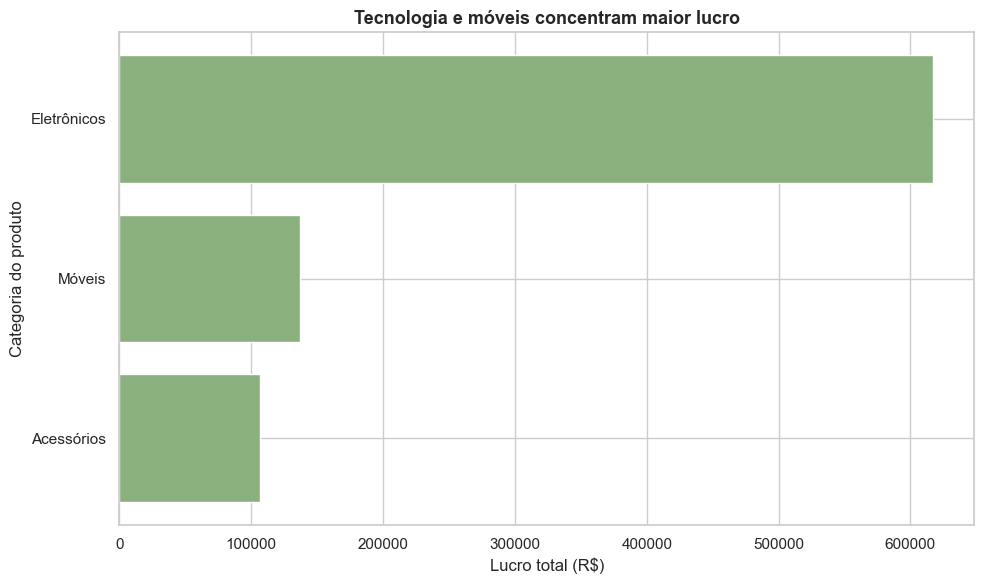

,categoria,lucro
0,Acessórios,106581.3625
2,Móveis,136704.3375
1,Eletrônicos,617367.4600


In [12]:
lucro_por_categoria = (
    df.groupby("categoria", as_index=False)["lucro"]
    .sum()
    .sort_values("lucro", ascending=True)
)

plt.figure(figsize=(10, 6))
plt.barh(lucro_por_categoria["categoria"], lucro_por_categoria["lucro"], color="#8AB17D")
plt.title("Tecnologia e móveis concentram maior lucro", fontsize=13, weight="bold")
plt.xlabel("Lucro total (R$)")
plt.ylabel("Categoria do produto")
plt.tight_layout()
plt.show()

display(lucro_por_categoria.tail(5))

## 15. Entrega esperada

Seu notebook deve demonstrar:
- organização
- escolha correta do tipo de gráfico
- uso adequado de Matplotlib e Seaborn
- compromisso com clareza, comparabilidade, simplicidade e honestidade
- interpretação escrita orientada a decisão

### Mensagem principal da aula
Não basta plotar. É preciso **comunicar o sinal no meio do ruído**.
